In [43]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import numpy as np


### Dataset Description ###

The California Housing dataset is used for the regression task in this project. It contains information collected from the 1990 California census and consists of multiple numerical features describing housing characteristics, such as median income, house age, average number of rooms, and geographic location. The target variable is the median house value for each district.

All input features are standardized to have zero mean and unit variance to improve training stability and convergence of the neural network. The dataset is split into training, validation, and test sets for model development and evaluation.

In [44]:
data = fetch_california_housing()
X = data.data          # shape: (n_samples, n_features)
y = data.target        # shape: (n_samples,)

# Standardization:
# perform X' = (x-average)/std   for each feature.
scaler = StandardScaler()
X = scaler.fit_transform(X)

# print(X.shape)
# print(data.feature_names)
# print(data.DESCR)

# (20640, 8)
# ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [45]:
# We randomly separate the dasta set: 
# 70% for training
# 15% for validation
# 15% for testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [46]:
# Convert the numpy array to pytorch tensors:
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


In [47]:
# Prepare the data loader:
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


In [48]:
class RegressionNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 1)   # the output is a single value
        )

    def forward(self, x):
        return self.net(x)


In [49]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RegressionNN(input_dim=X.shape[1]).to(device)


In [50]:
criterion = nn.MSELoss()          # We use MSE here for regression problem.
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


In [51]:
# This function is to evaluate the model.
def evaluate_regression(model, loader):
    model.eval()
    loss_sum = 0.0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            preds = model(x).squeeze()
            loss = criterion(preds, y)

            loss_sum += loss.item() * y.size(0)
            total += y.size(0)

    return loss_sum / total


In [52]:
epochs = 200

# We are going to collect the loss after every epoch
train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train() # Use the training mode

    for x, y in train_loader: # Iterate over very batch of the training set
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()  # zero the gradient
        preds = model(x).squeeze() # The squeeze converts the (batch_size, 1) to (batch_size,)
        loss = criterion(preds, y) # Calculate the loss
        loss.backward()            # Back propagation
        optimizer.step()           # Update the weights

    # Use the previous function to evaluate the traning set and valiation set after going through every epoch.
    train_loss = evaluate_regression(model, train_loader)
    val_loss   = evaluate_regression(model, val_loader)

    # collect the loss.
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | "
          f"Train MSE: {train_loss:.4f} | "
          f"Val MSE: {val_loss:.4f}")


Epoch 01 | Train MSE: 0.5539 | Val MSE: 0.5660
Epoch 02 | Train MSE: 0.4434 | Val MSE: 0.4570
Epoch 03 | Train MSE: 0.4246 | Val MSE: 0.4440
Epoch 04 | Train MSE: 0.4026 | Val MSE: 0.4193
Epoch 05 | Train MSE: 0.3816 | Val MSE: 0.3980
Epoch 06 | Train MSE: 0.3708 | Val MSE: 0.3894
Epoch 07 | Train MSE: 0.3734 | Val MSE: 0.3931
Epoch 08 | Train MSE: 0.3545 | Val MSE: 0.3740
Epoch 09 | Train MSE: 0.3498 | Val MSE: 0.3712
Epoch 10 | Train MSE: 0.3425 | Val MSE: 0.3636
Epoch 11 | Train MSE: 0.3486 | Val MSE: 0.3684
Epoch 12 | Train MSE: 0.3472 | Val MSE: 0.3684
Epoch 13 | Train MSE: 0.3342 | Val MSE: 0.3569
Epoch 14 | Train MSE: 0.3333 | Val MSE: 0.3523
Epoch 15 | Train MSE: 0.3220 | Val MSE: 0.3413
Epoch 16 | Train MSE: 0.3222 | Val MSE: 0.3418
Epoch 17 | Train MSE: 0.3126 | Val MSE: 0.3333
Epoch 18 | Train MSE: 0.3098 | Val MSE: 0.3325
Epoch 19 | Train MSE: 0.3089 | Val MSE: 0.3282
Epoch 20 | Train MSE: 0.3051 | Val MSE: 0.3242
Epoch 21 | Train MSE: 0.3007 | Val MSE: 0.3203
Epoch 22 | Tr

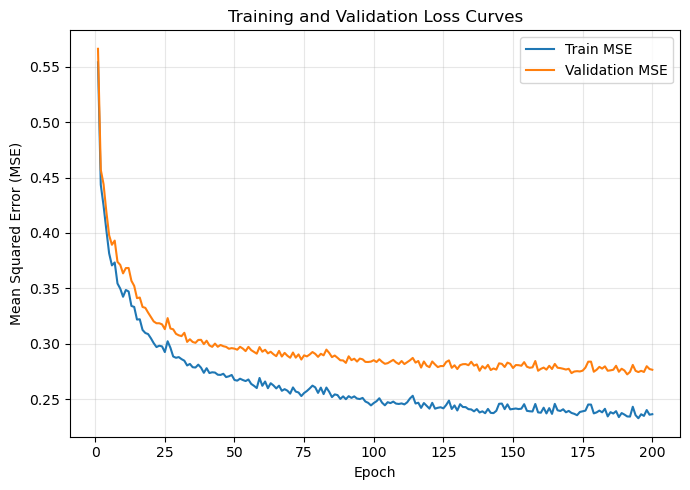

In [53]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_losses, label="Train MSE")
plt.plot(epochs, val_losses, label="Validation MSE")

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.title("Training and Validation Loss Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [54]:
# Evaluate the test set:
from sklearn.metrics import mean_squared_error, mean_absolute_error

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        preds = model(x).squeeze()

        all_preds.append(preds.cpu())
        all_labels.append(y)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

mse = mean_squared_error(all_labels, all_preds)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(all_labels, all_preds)

print("Test RMSE:", rmse)
print("Test MAE :", mae)


Test RMSE: 0.4922303226552255
Test MAE : 0.34164419770240784


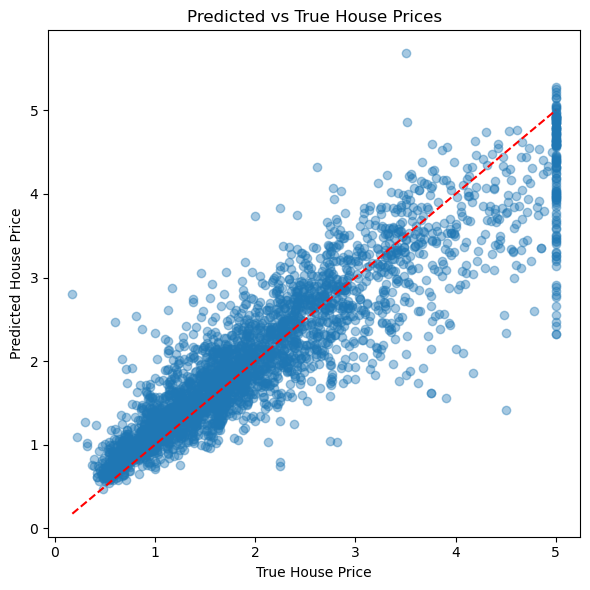

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(all_labels, all_preds, alpha=0.4)
plt.plot([all_labels.min(), all_labels.max()],
         [all_labels.min(), all_labels.max()],
         'r--')  # 理想预测线 y = x

plt.xlabel("True House Price")
plt.ylabel("Predicted House Price")
plt.title("Predicted vs True House Prices")
plt.tight_layout()
plt.show()


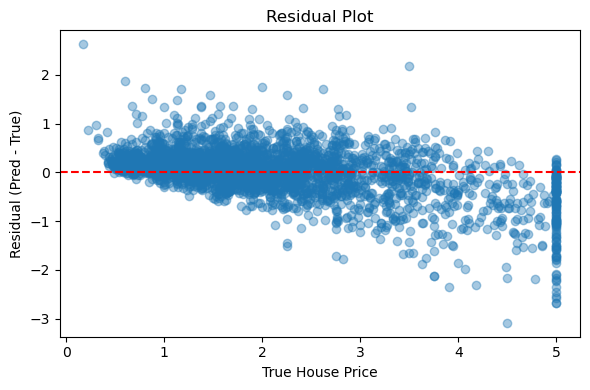

In [56]:
residuals = all_preds - all_labels

plt.figure(figsize=(6, 4))
plt.scatter(all_labels, residuals, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")

plt.xlabel("True House Price")
plt.ylabel("Residual (Pred - True)")
plt.title("Residual Plot")
plt.tight_layout()
plt.show()
